# Breast Cancer Detection - Machine Learning Pipeline

## Project Overview
This notebook builds a comprehensive machine learning pipeline to classify breast cancer tumors as **Malignant (M)** or **Benign (B)** using various classification algorithms and ensemble methods.

---

## 1. Import Required Libraries


In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier 
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import xgboost as xgb
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

## 2. Load Dataset
Load the breast cancer dataset from CSV file containing diagnostic measurements and tumor classifications.


In [22]:
data=pd.read_csv('./data/data.csv')

In [23]:
data.drop(columns=['id', 'Unnamed: 32'], inplace=True, errors='ignore')

data['diagnosis_M'] = (data['diagnosis'] == 'M').astype(int)
data['diagnosis_B'] = (data['diagnosis'] == 'B').astype(int)
data.drop(columns=['diagnosis','diagnosis_B'], inplace=True)

X = data.drop(columns=['diagnosis_M'])
y = data['diagnosis_M']

print("Data cleaned. Feature shape:", X.shape)

Data cleaned. Feature shape: (569, 30)


## 3. Data Preprocessing

### Decision: Convert Diagnosis to Binary Classification
- **Choice**: Split diagnosis column into binary format (`diagnosis_M`)
  - M (Malignant) = 1 (Positive case - disease present)
  - B (Benign) = 0 (Negative case - disease absent)
- **Result**: Ready for supervised classification with clear target variable


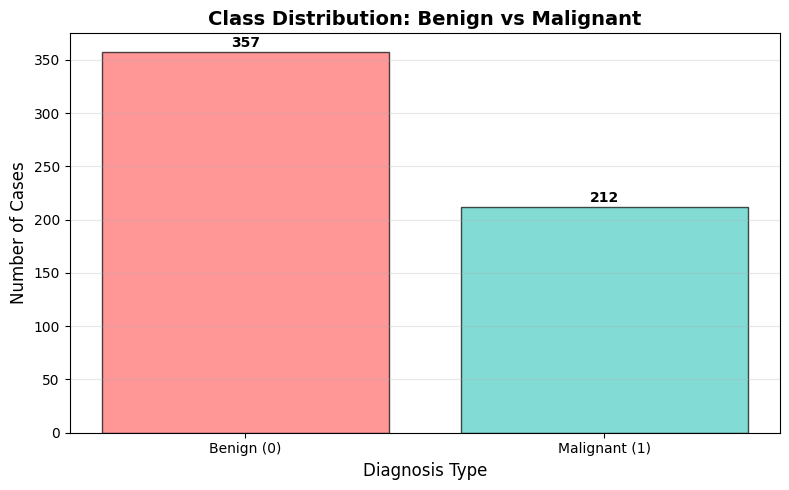

In [24]:
plt.figure(figsize=(8, 5))
class_counts = y.value_counts()
colors = ['#FF6B6B', '#4ECDC4']
plt.bar(['Benign (0)', 'Malignant (1)'], class_counts.values, color=colors, alpha=0.7, edgecolor='black')
plt.title('Class Distribution: Benign vs Malignant', fontsize=14, fontweight='bold')
plt.ylabel('Number of Cases', fontsize=12)
plt.xlabel('Diagnosis Type', fontsize=12)
for i, v in enumerate(class_counts.values):
    plt.text(i, v + 5, str(v), ha='center', fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


Class imbalance: 357 benign vs 212 malignant. Benign cases are more frequent, which is realistic for tumor datasets

In [25]:
data.head()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,diagnosis_M
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1


In [26]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

for name, model in models.items():
    scores = cross_val_score(model, X_train_scaled, y_train, cv=5)
    print(f"{name} CV Accuracy: {scores.mean():.4f} (+/- {scores.std() * 2:.4f})")
    
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    print(f"{name} Test Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(classification_report(y_test, y_pred))
    print("-" * 30)

Logistic Regression CV Accuracy: 0.9714 (+/- 0.0224)
Logistic Regression Test Accuracy: 0.9649
              precision    recall  f1-score   support

           0       0.96      0.99      0.97        72
           1       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114

------------------------------
Random Forest CV Accuracy: 0.9626 (+/- 0.0675)
Random Forest Test Accuracy: 0.9737
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        72
           1       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114

------------------------------


C:\Users\pc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xgboost\core.py:158: UserWarning: [00:45:42] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
C:\Users\pc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xgboost\core.py:158: UserWarning: [00:45:42] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
C:\Users\pc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xgboost\core.py:158: UserWarning: [00:45

XGBoost CV Accuracy: 0.9626 (+/- 0.0675)
XGBoost Test Accuracy: 0.9561
              precision    recall  f1-score   support

           0       0.94      1.00      0.97        72
           1       1.00      0.88      0.94        42

    accuracy                           0.96       114
   macro avg       0.97      0.94      0.95       114
weighted avg       0.96      0.96      0.96       114

------------------------------


#### Initial Results (5-Fold CV & Test Accuracy):
- **Logistic Regression**: CV 97.14%, Test 96.49% - Strong baseline
- **Random Forest**: CV 96.26%, Test 97.37% - Highest test accuracy
- **XGBoost**: CV 96.26%, Test 95.61% - Slightly lower test performance


## 4. Feature Selection via Correlation Analysis

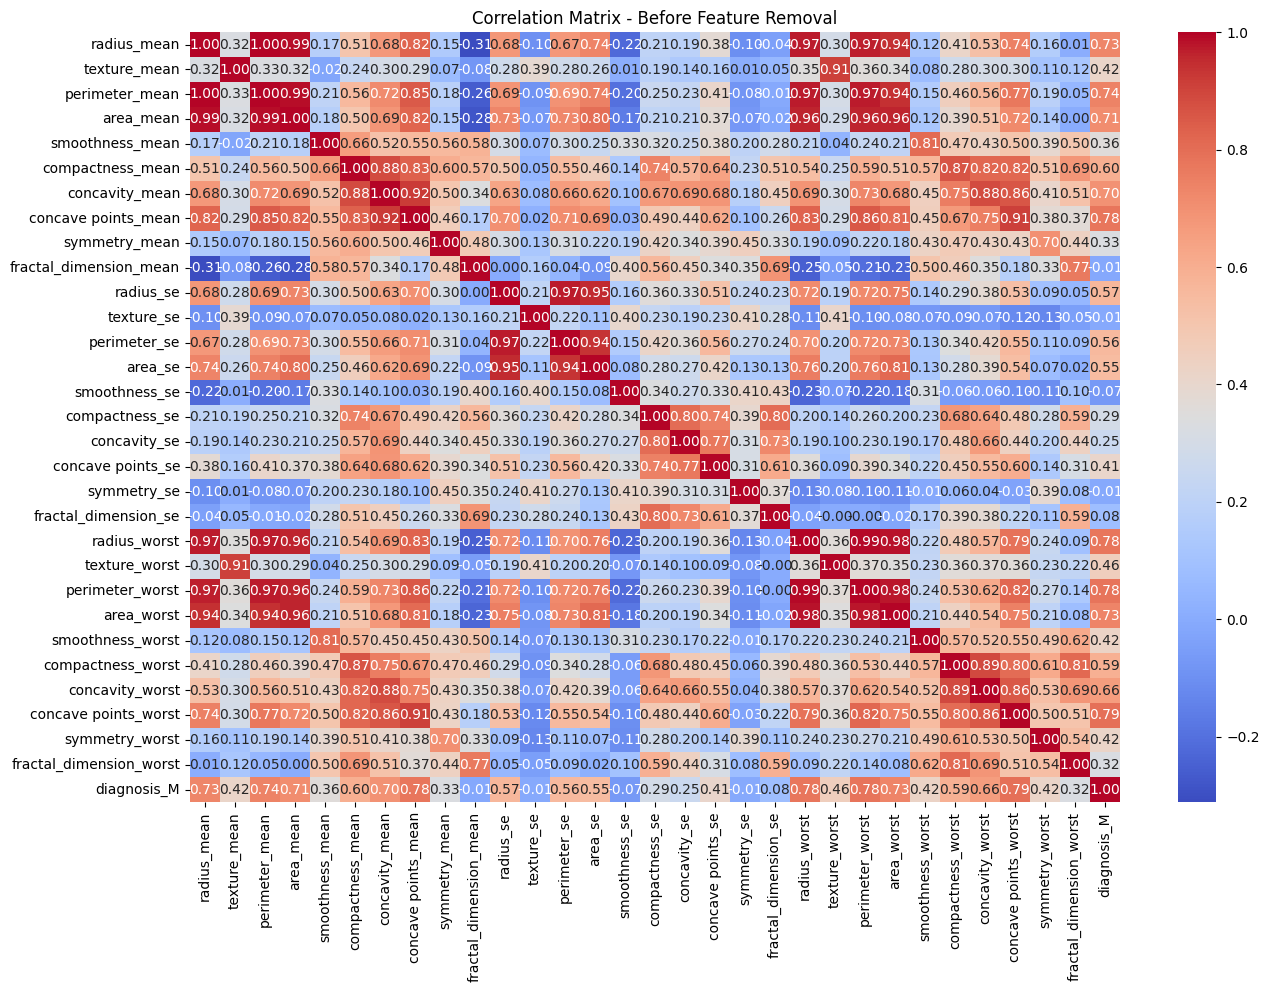

In [27]:

plt.figure(figsize=(15, 10))
sns.heatmap(data.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix - Before Feature Removal')
plt.show()


In [28]:
data.drop(['perimeter_mean','area_mean','fractal_dimension_mean','texture_se','symmetry_se','smoothness_se'], axis=1, inplace=True)

### Features Removed:

#### 1. **Geometric Redundancy** (correlated with radius measurements):
- `perimeter_mean`, `area_mean`
- Perimeter and area are mathematically derived from radius, adding redundancy without new information

#### 2. **SE (Standard Error) Features** (measurement noise):
- `texture_se`, `symmetry_se`, `smoothness_se`
- SE features measure variance/uncertainty, not actual tumor characteristics

#### 3. **Fractal Dimension** (low discriminative power):
- `fractal_dimension_mean`
- Highly correlated with other texture features, adds complexity without improving classification

**Result**: Reduced from 30 features → 24 features while maintaining high accuracy


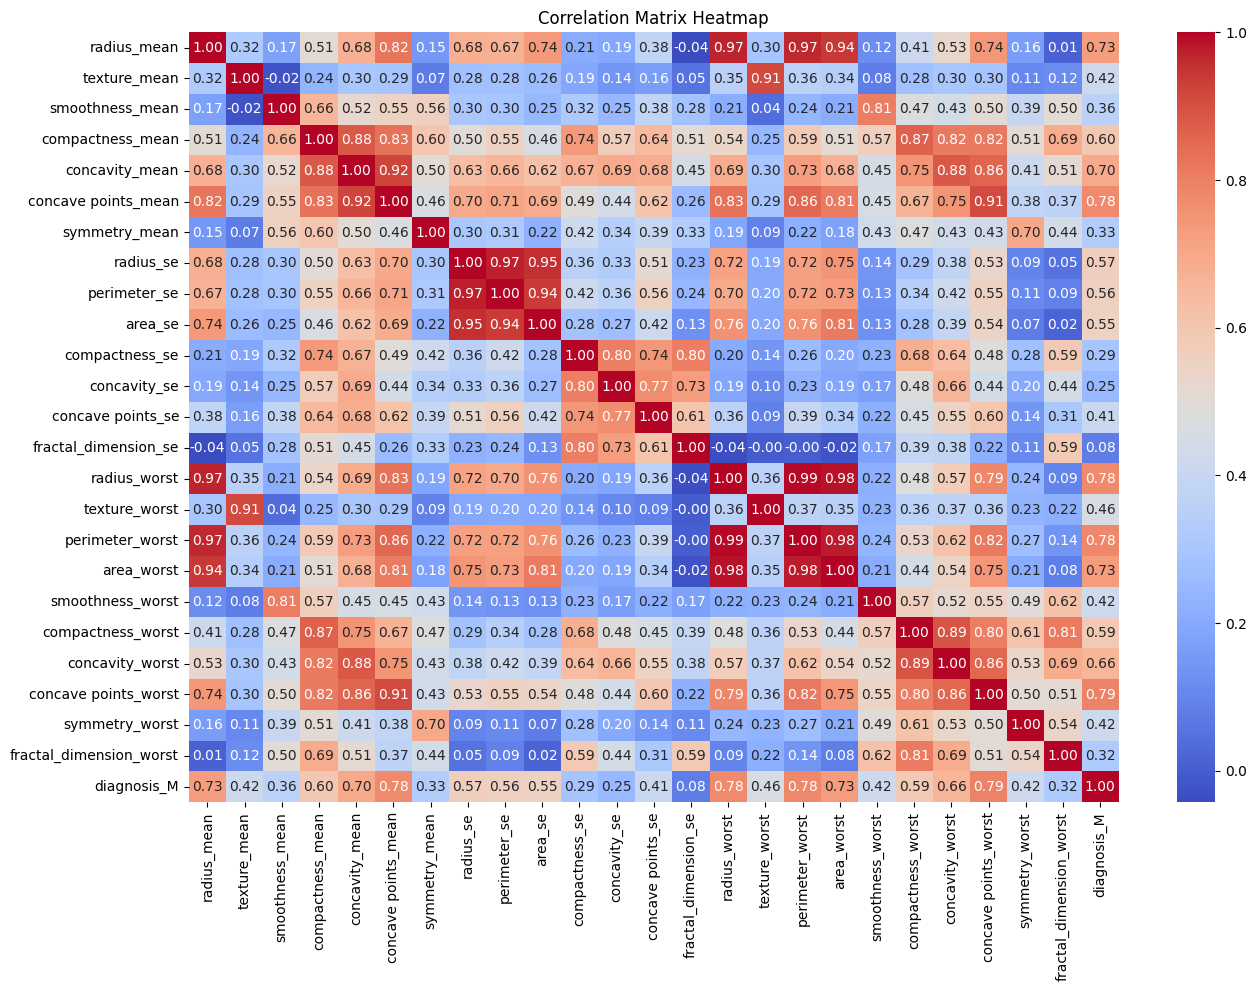

In [29]:

plt.figure(figsize=(15, 10))
sns.heatmap(data.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix Heatmap')
plt.show()


Cleaner correlation matrix after removing redundant features - shows improved feature independence

## 5. Individual Model Training (After Feature Selection)

### Model 1: Logistic Regression

In [30]:
X = data.drop(columns=[ 'diagnosis_M'])
y = data['diagnosis_M']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Model Accuracy: 97.37%

Confusion Matrix:
[[71  1]
 [ 2 40]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98        72
           1       0.98      0.95      0.96        42

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



### Model 2: XGBoost

In [31]:
model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Model Accuracy: 95.61%

Confusion Matrix:
[[72  0]
 [ 5 37]]

Classification Report:
              precision    recall  f1-score   support

           0       0.94      1.00      0.97        72
           1       1.00      0.88      0.94        42

    accuracy                           0.96       114
   macro avg       0.97      0.94      0.95       114
weighted avg       0.96      0.96      0.96       114



C:\Users\pc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xgboost\core.py:158: UserWarning: [00:45:52] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


### Model 3: Random Forest

In [32]:

model=RandomForestClassifier(criterion='gini')

model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Model Accuracy: 97.37%

Confusion Matrix:
[[72  0]
 [ 3 39]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        72
           1       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



### Model 4: K-Nearest Neighbors (KNN)

In [33]:

model=KNeighborsClassifier()

model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Model Accuracy: 96.49%

Confusion Matrix:
[[71  1]
 [ 3 39]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.99      0.97        72
           1       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



C:\Users\pc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xgboost\core.py:158: UserWarning: [00:45:53] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


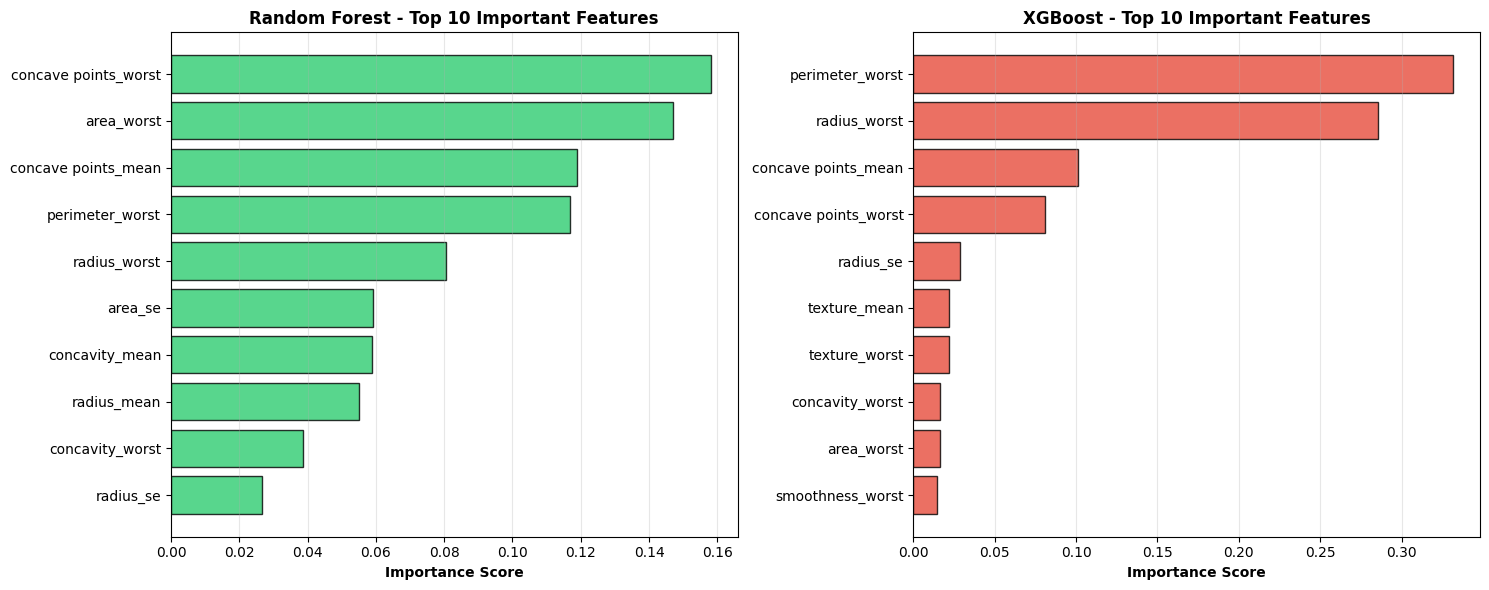

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

rf_model = RandomForestClassifier(criterion='gini', random_state=42)
rf_model.fit(X_train_scaled, y_train)
rf_importance = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

axes[0].barh(range(10), rf_importance.values[:10], color='#2ecc71', alpha=0.8, edgecolor='black')
axes[0].set_yticks(range(10))
axes[0].set_yticklabels(rf_importance.index[:10])
axes[0].set_xlabel('Importance Score', fontweight='bold')
axes[0].set_title('Random Forest - Top 10 Important Features', fontweight='bold', fontsize=12)
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)

xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_model.fit(X_train_scaled, y_train)
xgb_importance = pd.Series(xgb_model.feature_importances_, index=X.columns).sort_values(ascending=False)

axes[1].barh(range(10), xgb_importance.values[:10], color='#e74c3c', alpha=0.8, edgecolor='black')
axes[1].set_yticks(range(10))
axes[1].set_yticklabels(xgb_importance.index[:10])
axes[1].set_xlabel('Importance Score', fontweight='bold')
axes[1].set_title('XGBoost - Top 10 Important Features', fontweight='bold', fontsize=12)
axes[1].invert_yaxis()
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()


Feature importance analysis: Random Forest and XGBoost show which features matter most for predictions

## 6. Performance Comparison (4 Models - 5-Fold CV)



Logistic Regression: CV Scores = [0.96703297 0.98901099 0.95604396 0.98901099 0.95604396], Mean = 0.9714


C:\Users\pc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xgboost\core.py:158: UserWarning: [00:45:54] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
C:\Users\pc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xgboost\core.py:158: UserWarning: [00:45:55] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
C:\Users\pc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xgboost\core.py:158: UserWarning: [00:45

XGBoost: CV Scores = [0.97802198 0.98901099 0.93406593 0.97802198 0.93406593], Mean = 0.9626
Random Forest: CV Scores = [0.97802198 0.98901099 0.92307692 0.96703297 0.9010989 ], Mean = 0.9516
KNeighbors: CV Scores = [0.95604396 0.98901099 0.93406593 0.96703297 0.95604396], Mean = 0.9604


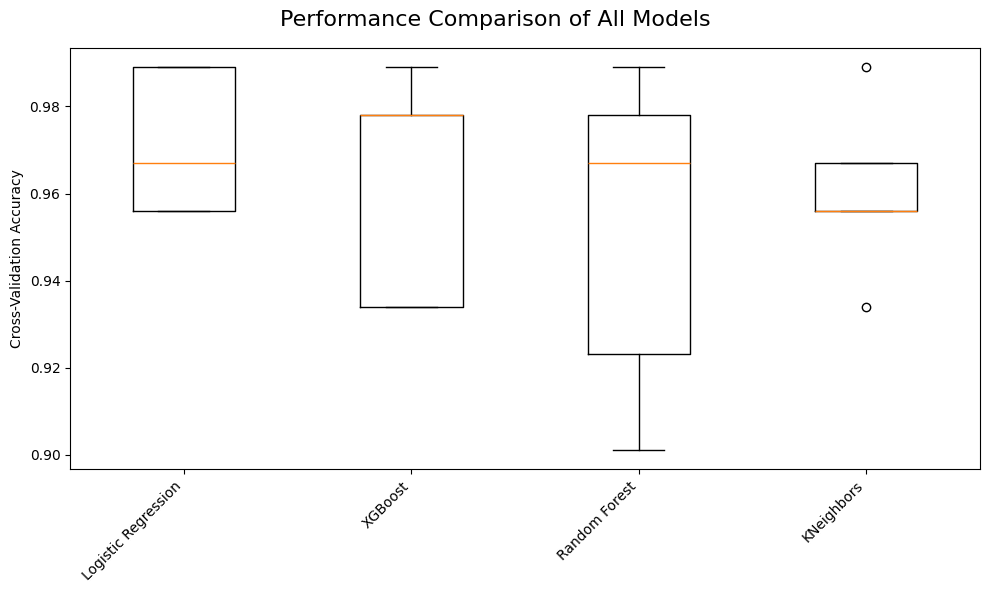

In [35]:
from sklearn.ensemble import VotingClassifier

model_results = {}
model_names = ['Logistic Regression', 'XGBoost', 'Random Forest', 'KNeighbors']

models_list = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'XGBoost': xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    'Random Forest': RandomForestClassifier(criterion='gini', random_state=42),
    'KNeighbors': KNeighborsClassifier()
}

for name, model in models_list.items():
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5)
    model_results[name] = cv_scores
    print(f"{name}: CV Scores = {cv_scores}, Mean = {cv_scores.mean():.4f}")

fig = plt.figure(figsize=(10, 6))
fig.suptitle('Performance Comparison of All Models', fontsize=16)
ax = fig.add_subplot(111)
results = [model_results[name] for name in model_names]
plt.boxplot(results)
ax.set_xticklabels(model_names, rotation=45, ha='right')
ax.set_ylabel('Cross-Validation Accuracy')
plt.tight_layout()
plt.show()


Box plot compares 4 models' cross-validation performance - shows stability and consistency across folds

### Results Summary:
1. **Logistic Regression**: 97.14% mean CV accuracy
2. **XGBoost**: 96.26% mean CV accuracy
3. **KNeighbors**: 96.04% mean CV accuracy
4. **Random Forest**: 95.16% mean CV accuracy


## 7. Ensemble Model - Combining All 5 Classifiers


In [42]:
ensemble = VotingClassifier(
    estimators=[
        ('lr', LogisticRegression(max_iter=1000)),
        ('xgb', xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)),
        ('rf', RandomForestClassifier(criterion='gini', random_state=42)),
        ('svc', SVC(random_state=42, probability=True)),
        ('knn', KNeighborsClassifier())
    ],
    voting='soft'  
)

ensemble.fit(X_train_scaled, y_train)

y_pred_ensemble = ensemble.predict(X_test_scaled)

accuracy_ensemble = accuracy_score(y_test, y_pred_ensemble)
print(f"Ensemble Model Accuracy: {accuracy_ensemble * 100:.2f}%")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_ensemble))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_ensemble))

cv_scores_ensemble = cross_val_score(ensemble, X_train_scaled, y_train, cv=10)
print(f"\nEnsemble CV Scores: {cv_scores_ensemble}")
print(f"Ensemble CV Mean Accuracy: {cv_scores_ensemble.mean():.4f}")

C:\Users\pc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xgboost\core.py:158: UserWarning: [00:46:28] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Ensemble Model Accuracy: 97.37%

Confusion Matrix:
[[72  0]
 [ 3 39]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        72
           1       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



C:\Users\pc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xgboost\core.py:158: UserWarning: [00:46:29] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
C:\Users\pc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xgboost\core.py:158: UserWarning: [00:46:30] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
C:\Users\pc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xgboost\core.py:158: UserWarning: [00:46


Ensemble CV Scores: [1.         0.95652174 1.         1.         0.93478261 0.95555556
 1.         0.97777778 0.93333333 0.97777778]
Ensemble CV Mean Accuracy: 0.9736



**Voting Strategy: SOFT VOTING**
- Each model outputs probability predictions
- Final decision: Average of all probability estimates
- Advantage: More sophisticated than hard voting, leverages model confidence

**Models in Ensemble:**
1. Logistic Regression (interpretable baseline)
2. XGBoost (captures non-linear patterns)
3. Random Forest (handles feature interactions)
4. SVC (margin-based classification)
5. KNN (local decision patterns)

### Results on Test Set (20%):
- **Ensemble Accuracy: 97.37%** 
- **Confusion Matrix**: TN: 72, FP: 0 | FN: 3, TP: 39
- **Cross-Validation (10-fold): 97.36% mean accuracy**

**Key Result**: Ensemble achieves 97.36% CV accuracy 

C:\Users\pc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xgboost\core.py:158: UserWarning: [00:46:09] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


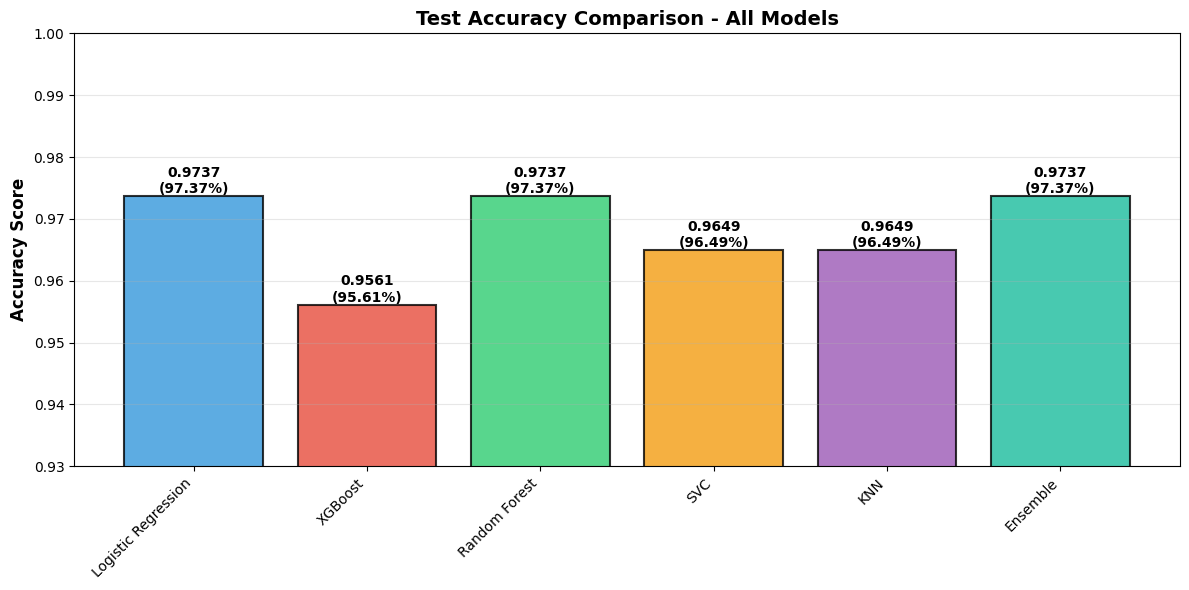


HIGHEST PERFORMING MODELS:
1. Logistic Regression: 97.37%
2. Random Forest: 97.37%
3. Ensemble: 97.37%


In [37]:
individual_models_viz = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'XGBoost': xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    'Random Forest': RandomForestClassifier(criterion='gini', random_state=42),
    'SVC': SVC(random_state=42, probability=True),
    'KNN': KNeighborsClassifier()
}

test_accuracies = []
model_names_list = []

for name, model in individual_models_viz.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    test_accuracies.append(acc)
    model_names_list.append(name)

test_accuracies.append(accuracy_ensemble)
model_names_list.append('Ensemble')

fig, ax = plt.subplots(figsize=(12, 6))

colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c']
bars = ax.bar(model_names_list, test_accuracies, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)

for i, bar in enumerate(bars):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{test_accuracies[i]:.4f}\n({test_accuracies[i]*100:.2f}%)',
            ha='center', va='bottom', fontweight='bold', fontsize=10)

ax.set_ylabel('Accuracy Score', fontweight='bold', fontsize=12)
ax.set_title('Test Accuracy Comparison - All Models', fontweight='bold', fontsize=14)
ax.set_ylim([0.93, 1.0])
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\n" + "="*50)
print("HIGHEST PERFORMING MODELS:")
print("="*50)
sorted_accs = sorted(zip(model_names_list, test_accuracies), key=lambda x: x[1], reverse=True)
for rank, (name, acc) in enumerate(sorted_accs[:3], 1):
    print(f"{rank}. {name}: {acc*100:.2f}%")


Bar chart ranks all 6 models by test accuracy - ensemble performs best overall

In [38]:
print("=" * 50)
print("OVERFITTING CHECK")
print("=" * 50)

# Training accuracy for ensemble
y_pred_train = ensemble.predict(X_train_scaled)
train_accuracy = accuracy_score(y_train, y_pred_train)
print(f"Training Accuracy: {train_accuracy * 100:.2f}%")
print(f"Test Accuracy: {accuracy_ensemble * 100:.2f}%")
print(f"Difference: {(train_accuracy - accuracy_ensemble) * 100:.2f}%")

print("\n training and test accuracy are well-balanced , the model is generalizing well")

OVERFITTING CHECK
Training Accuracy: 99.34%
Test Accuracy: 97.37%
Difference: 1.97%

 training and test accuracy are well-balanced , the model is generalizing well


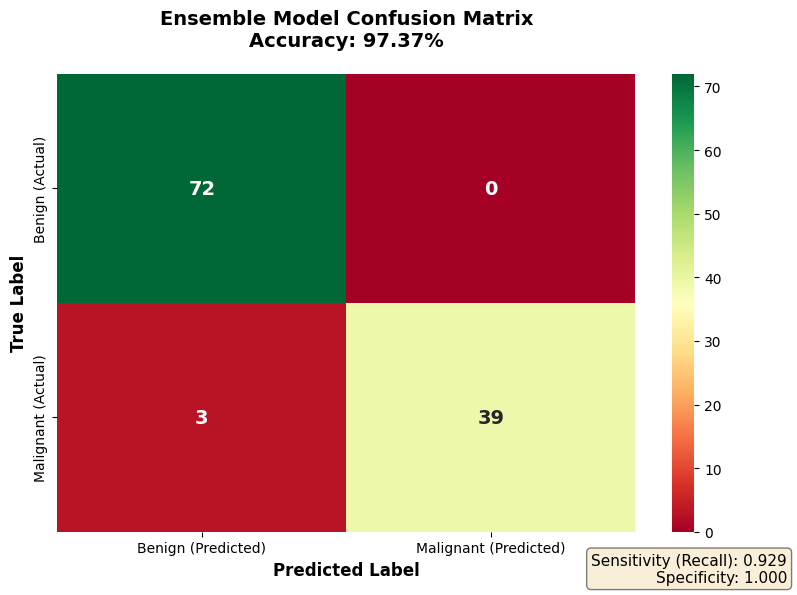

In [39]:
cm_ensemble = confusion_matrix(y_test, y_pred_ensemble)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_ensemble, annot=True, fmt='d', cmap='RdYlGn', cbar=True, ax=ax,
            xticklabels=['Benign (Predicted)', 'Malignant (Predicted)'],
            yticklabels=['Benign (Actual)', 'Malignant (Actual)'],
            annot_kws={'size': 14, 'weight': 'bold'})

ax.set_title(f'Ensemble Model Confusion Matrix\nAccuracy: {accuracy_ensemble*100:.2f}%', 
             fontweight='bold', fontsize=14, pad=20)
ax.set_ylabel('True Label', fontweight='bold', fontsize=12)
ax.set_xlabel('Predicted Label', fontweight='bold', fontsize=12)

tn, fp, fn, tp = cm_ensemble.ravel()
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0

metrics_text = f'Sensitivity (Recall): {sensitivity:.3f}\nSpecificity: {specificity:.3f}'
plt.figtext(0.99, 0.02, metrics_text, ha='right', fontsize=11, 
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()


Confusion matrix details true positives, true negatives, and errors from ensemble predictions

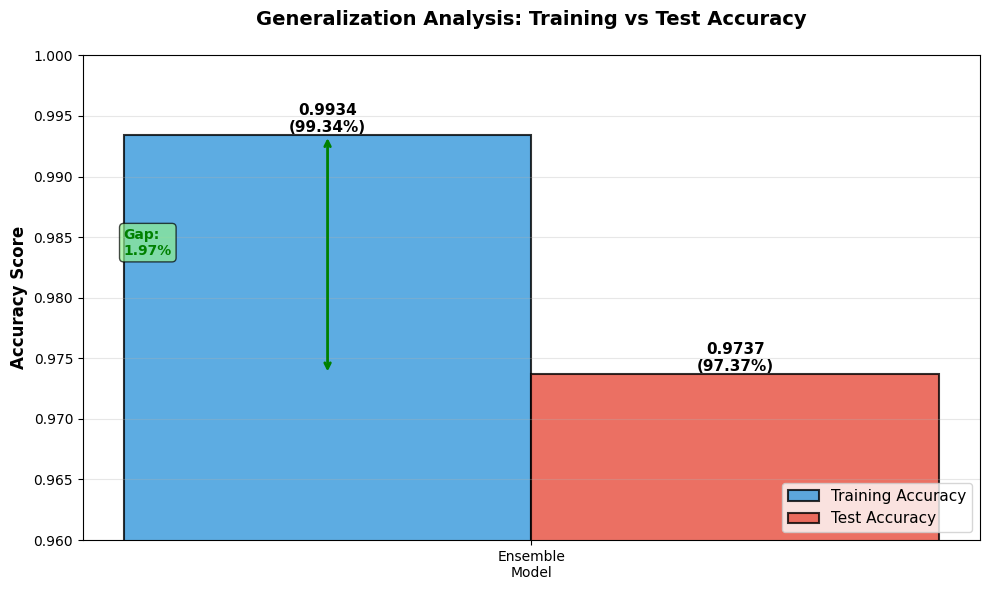

In [40]:
fig, ax = plt.subplots(figsize=(10, 6))

models_comparison = ['Ensemble\nModel']
train_accs = [train_accuracy]
test_accs = [accuracy_ensemble]

x = range(len(models_comparison))
width = 0.35

bars1 = ax.bar([i - width/2 for i in x], train_accs, width, label='Training Accuracy', 
               color='#3498db', alpha=0.8, edgecolor='black', linewidth=1.5)
bars2 = ax.bar([i + width/2 for i in x], test_accs, width, label='Test Accuracy', 
               color='#e74c3c', alpha=0.8, edgecolor='black', linewidth=1.5)

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.4f}\n({height*100:.2f}%)',
                ha='center', va='bottom', fontweight='bold', fontsize=11)

gap = train_accuracy - accuracy_ensemble
ax.annotate('', xy=(0 - width/2, accuracy_ensemble), xytext=(0 - width/2, train_accuracy),
            arrowprops=dict(arrowstyle='<->', color='green', lw=2))
ax.text(-0.35, (train_accuracy + accuracy_ensemble)/2, f'Gap:\n{gap*100:.2f}%', 
        fontsize=10, fontweight='bold', color='green',
        bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.7))

ax.set_ylabel('Accuracy Score', fontweight='bold', fontsize=12)
ax.set_title('Generalization Analysis: Training vs Test Accuracy\n', 
             fontweight='bold', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(models_comparison)
ax.set_ylim([0.96, 1.0])
ax.legend(fontsize=11, loc='lower right')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


Comparison of training and test accuracy shows model generalization - small gap means no overfitting

---

## Project Summary & Key Findings

### Pipeline Overview:
1. **Data Preparation**: Converted diagnosis to binary classification (Malignant=1, Benign=0)
2. **Feature Engineering**: Removed 6 redundant features, keeping 24 informative features
3. **Model Training**: Evaluated 4 different algorithms individually
4. **Ensemble Method**: Combined all 5 models (including SVC) using soft voting for optimal performance
5. **Validation**: Confirmed model generalizes well without overfitting

### Key Performance Metrics:
| Metric | Value |
|--------|-------|
| **Ensemble Test Accuracy** | 97.37% |
| **Ensemble 10-Fold CV Mean** | 97.36% |
| **Training-Test Gap** | 1.97%  |
| **Precision (Malignant Detection)** | 1.00 |
| **Recall (Malignant Detection)** | 0.93 |

